### **Introduction au Machine Learning et Prétraitement des Données**

---

## **Introduction**

Dans ce notebook, nous allons aborder les bases du Machine Learning, apprendre comment organiser notre travail de manière efficace, et explorer en profondeur les données pour mieux comprendre leur structure et les préparer pour la modélisation.

## **Objectifs**

À la fin de ce notebook, vous serez capable de :
1. Decouvrire les applications du Machine Learning.
2. Organiser votre environnement de travail pour une gestion optimale des données et du code.
3. Explorer et analyser les données pour en tirer des insights initiaux.
4. Appliquer des techniques de prétraitement de données telles que la gestion des valeurs manquantes, l’encodage des variables, la gestion des valeurs aberrantes, la normalisation, et d'autres transformations.

---


## **1. Introduction au Machine Learning**

### Définition

Le **Machine Learning (ML)**, ou apprentissage automatique, est une branche de l'intelligence artificielle qui permet aux machines d'apprendre à partir de données. L’objectif du Machine Learning est de construire des modèles capables de réaliser des tâches spécifiques (comme des prédictions ou des classifications) en analysant des données, sans être explicitement programmés pour chaque tâche.

**Exemples d'applications business** :
- **Prédiction de churn client** : Prédire si un client risque de quitter une entreprise, pour orienter les actions de fidélisation.
- **Scoring de crédit** : Évaluer le risque associé à l’octroi de crédit.
- **Recommandation de produits** : Systèmes de recommandation utilisés par les plateformes e-commerce.

**Question** : 
Pouvez-vous penser à d'autres applications du Machine Learning qui seraient utiles dans le contexte de l’entreprise ?
---

### Workflow Typique de Création d’un Modèle de Machine Learning

Un modèle de Machine Learning suit généralement les étapes suivantes :
1. **Définition de l’objectif** : Identifier la tâche (classification, régression, etc.).
2. **Exploration des données** : Étudier les données disponibles pour comprendre leur structure et leurs caractéristiques.
3. **Prétraitement des données** : Nettoyer et transformer les données pour les rendre exploitables.
4. **Entraînement du modèle** : Choisir et entraîner un algorithme de Machine Learning.
5. **Évaluation et amélioration** : Mesurer les performances du modèle et apporter des améliorations si nécessaire.

---

## **2. Organisation de l’Environnement de Travail**

Pour bien gérer vos données, notebooks, et scripts, il est recommandé d’organiser votre répertoire de travail de manière structurée.

### Structure du Répertoire

Voici une structure recommandée :
- **notebooks/** : Contient les notebooks Jupyter pour chaque module.
- **data/** : Contient les fichiers de données à utiliser dans le projet. Stockez tous les jeux de données ici pour une meilleure organisation.
- **scripts/** : Contient les fichiers `.py` avec des fonctions ou du code réutilisable.

Par exemple, si notre dataset `titanic.csv` est stocké dans le dossier `data` au même niveau que `notebooks`, on peut l’appeler en utilisant le chemin relatif `../data/titanic.csv`.

---

## **3. Exploration des Données**

### Définition

L'**exploration des données** (Exploratory Data Analysis - EDA) est le processus d'examen approfondi d'un jeu de données pour comprendre sa structure, identifier des patterns, et détecter des anomalies ou des valeurs aberrantes. L'objectif de l'EDA est de préparer la base pour les étapes de prétraitement et de modélisation.

### Objectifs de l’Exploration des Données

- **Comprendre la structure des données** : Observer les variables présentes, leur type (numérique, catégoriel) et leur distribution.
- **Identifier les valeurs manquantes et aberrantes** : Détecter les données incomplètes et les valeurs extrêmes, qui peuvent fausser l'analyse.
- **Déterminer les transformations nécessaires** : Décider des étapes de nettoyage et de transformation des données pour rendre les données exploitables.

### Outils et Méthodes Utilisés

Pour l'exploration des données, nous allons utiliser les bibliothèques :
- **Pandas** pour charger et manipuler les données.
- **Matplotlib et Seaborn** pour visualiser les distributions et les relations entre variables.

---

### **Extraction des Données**

Nous allons commencer par charger le dataset `titanic.csv`, qui contient des informations sur les passagers du Titanic.

**Instructions** :
1. Importez les bibliothèques **Pandas** et **NumPy**.
2. Chargez le dataset en utilisant `pd.read_csv()` et affichez les premières lignes avec `.head()` pour voir un aperçu.


In [1]:
import pandas as pd
import numpy as np

In [97]:
df_titanic = pd.read_csv("scripts/titanic.csv")
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Question** : En observant les premières lignes du dataset, que représentent les différentes colonnes ? Quels types de données semble-t-il y avoir dans ce dataset (numériques, catégorielles, etc.) ?

##### Les différentes colonnes représentent le numéro des passagers, leurs noms, sexes, âges (variables démographiques). Leurs tickets ainsi que leurs montants, la classe, la cabine et enfin depuis quel quai ils ont embarqué. Ils semblent y avoir des données numériques, catégorielles, textuels, binaires mais aussi des données manquantes.

---

### **Analyse Exploratoire des Données**

#### 1. **Dimensions et Types de Données** :
   - Utilisez `.shape` pour voir les dimensions du dataset et `.info()` pour obtenir des informations sur les types de données.

In [3]:
df_titanic.shape

(891, 12)

In [4]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Questions** :
   - Combien de colonnes et de lignes contient ce dataset ? Qu’est-ce que cela nous indique sur sa taille ?
   - Quels types de données sont présents ? Pourquoi est-il important de connaître les types avant de commencer l’analyse ?

##### Il contient 12 colonnes et 891 lignes. Cela nous indique que sa taille est relativement petit pour un dataset (probablement un peu plus facile à manipuler). 
##### Les types de données présents sont integers / float / string (nombres entiers, décimaux et chaînes de caractères).

#### 2. **Statistiques Descriptives - Variables Numériques** :
   - Utilisez `.describe()` pour obtenir des statistiques sur les variables numériques (moyenne, écart-type, etc.).


In [5]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Questions** :
   - Que représentent les valeurs de sortie pour chaque statistique ?
   - Pouvez-vous identifier des valeurs extrêmes ou des anomalies potentielles ?


##### valeurs de sortie pour chaque statistique : 
##### count = nombre de valeurs non manquantes
##### mean = la moyenne des valeurs
##### std = l'écart-type, qui indique à quel point les valeurs sont dispersées autour de la moyenne
##### min = la plus petite valeur
##### 25% = 1er quartile (Q1) : 25 % des valeurs sont inférieures ou égales à cette valeur
##### 50% = médiane (Q2) : 50 % des valeurs sont inférieures ou égales à cette valeur
##### 75% = 3e quartile (Q3) : 75 % des valeurs sont inférieures ou égales à cette valeur
##### max = la plus grande valeur
##### 
##### En valeur extrême, il y a dans la colonne "Fare" le max qui est très éloigné des 75%, ce qui peut signifier un énorme écart dans le prix des billets.

#### 3. **Statistiques Descriptives - Variables Catégorielles** :
   - Utilisez `.describe(include=['O'])` pour obtenir des statistiques descriptives sur les variables catégorielles (type `object`).

In [6]:
df_titanic.describe(include=['str'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


**Question** : Combien de catégories uniques existe-t-il pour chaque variable catégorielle ? En quoi ces informations pourraient-elles être utiles lors de la modélisation ?

##### Il existe ici 5 catégories uniques pour chaque variable catégorielle. Elles sont importante à prendre en compte lors du paramétrage (encoding) pour éviter le ralentissement du modèle, ainsi que d'avoir trop de paramètres à prendre en compte (overfitting).

#### 4. **Visualisation des Données**

1. **Visualisation de la Distribution de l'Âge** :
   - Utilisez `sns.histplot()` pour afficher l’histogramme de la distribution de l'âge (`Age`).

<Axes: xlabel='Age', ylabel='Count'>

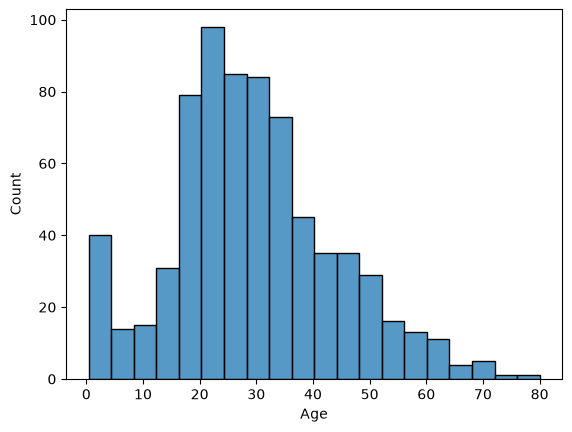

In [7]:
import seaborn as sns
sns.histplot(df_titanic['Age'])

**Questions** :
   - Que représente chaque barre de l'histogramme ? Quels âges semblent les plus courants parmi les passagers ?
   - En quoi la distribution de l'âge pourrait-elle influencer une analyse business ?

##### chaque barre de l'histogramme représente la proportion de personnes ayant l'âge figurant sur l'ordre des abscisses. L'âge le plus courant semble être entre 21 et 23 ans.
#####
##### La distribution de l'âge peux influencer une analyse business car l'âge est directement relier aux habitudes de consommation, d'achat et comportementales. Il faut aussi prendre en compte que les besoins évoluent avec l'âge.

2. **Visualisation de la Distribution de la variable `Fare`** :
   - Utilisez `sns.histplot()` pour afficher l’histogramme de la distribution de la variable `Fare`.

<Axes: xlabel='Fare', ylabel='Count'>

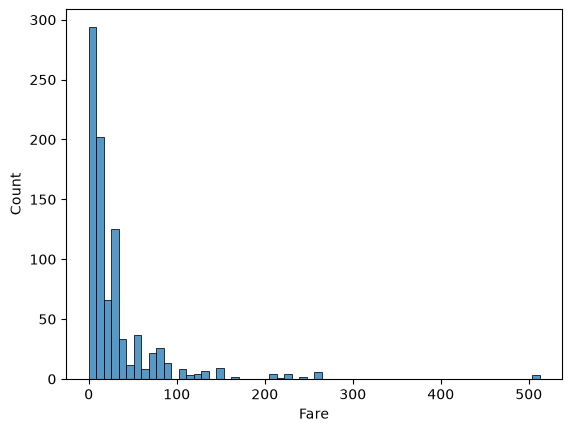

In [8]:
sns.histplot(df_titanic['Fare'])

3. **Corrélations entre Variables Numériques** :

 > **Corrélation** : La corrélation mesure la force et la direction de la relation entre deux variables. Une corrélation proche de 1 ou -1 indique une relation forte, tandis qu'une corrélation proche de 0 indique une relation faible.

   - Utilisez `.corr()` pour calculer la corrélation entre les variables numériques, puis visualisez avec `sns.heatmap()`.

In [9]:
df_corr_num = df_titanic.describe().corr()
df_corr_num

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.521032,0.522038,0.595323,0.525557,0.523936,0.768955
Survived,0.521032,1.000000,0.999997,0.995506,0.999971,0.999983,0.854290
Pclass,0.522038,0.999997,1.000000,0.995603,0.999969,0.999981,0.854411
Age,0.595323,0.995506,0.995603,1.000000,0.996106,0.995928,0.894249
SibSp,0.525557,0.999971,0.999969,0.996106,1.000000,0.999998,0.858250
Parch,0.523936,0.999983,0.999981,0.995928,0.999998,1.000000,0.857221
Fare,0.768955,0.854290,0.854411,0.894249,0.858250,0.857221,1.000000


<Axes: >

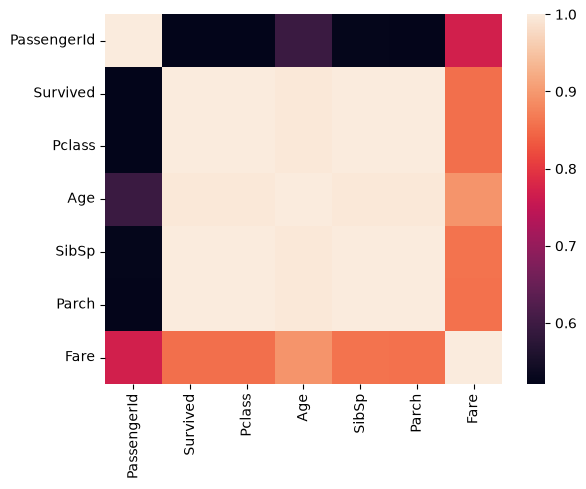

In [10]:
sns.heatmap(df_corr_num)

**Questions** :
   - Quelles sont les variables fortement corrélées entre elles ? Comment interpréter ces corrélations ?
   - Pourquoi est-il important de connaître les corrélations pour éviter les redondances dans les variables ?

##### Les variables fortement corrélées entres elles sont Survived, Pclass, Age, SibSp, et Parch. Cela signifie que la plupart des données du fichier sont fortement corrélés.
#####
##### Il est important de savoir les corrélations (et éviter les redondances dans les variables) pour éviter de fausser les résultats d'analyses des modèles.

#### 5. **Identification des Valeurs Manquantes**

   - Utilisez `.isnull().sum()` pour identifier les colonnes avec des valeurs manquantes.

In [11]:
df_titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Questions** :
   - Quelles colonnes contiennent des valeurs manquantes ? Quelle pourrait être la cause des valeurs manquantes ?
   - Comment le choix de traitement des valeurs manquantes peut-il impacter les résultats d’un modèle ?

##### Les colonnes qui contiennent des valeurs manquantes sont "Age", "Cabin" et "Embarked". Une des causes possibles peut être une perte des registres, ou bien des personnes qui sont décédés à bord du Titanic sans famillesz (et donc non identifiable).
#####
##### Le choix de traitement des valeurs manquantes peuvent impacter les résultats d'un modèle en introduisant des biais et fausser les résultats.

#### 6. Gestion des Valeurs Aberrantes (Outliers)

Les valeurs aberrantes (outliers) sont des valeurs extrêmes qui peuvent influencer les résultats de certains modèles. Une méthode simple pour les identifier est l’utilisation d’un **boxplot**.

- **Boxplot pour Identifier les Valeurs Aberrantes** :
   - Utilisez `sns.boxplot()` pour visualiser la distribution de l'âge et de `fare` et identifier les valeurs aberrantes.
   


<Axes: ylabel='Age'>

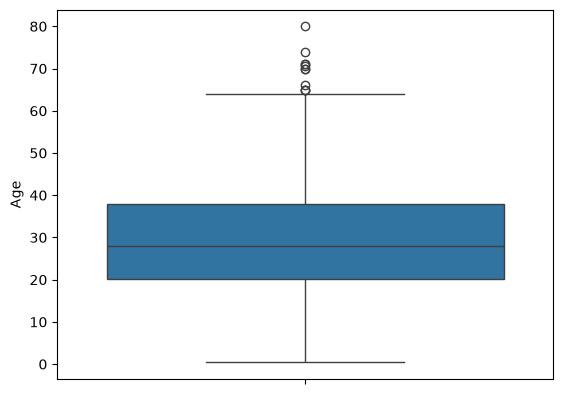

In [12]:
sns.boxplot(df_titanic['Age'])

<Axes: ylabel='Fare'>

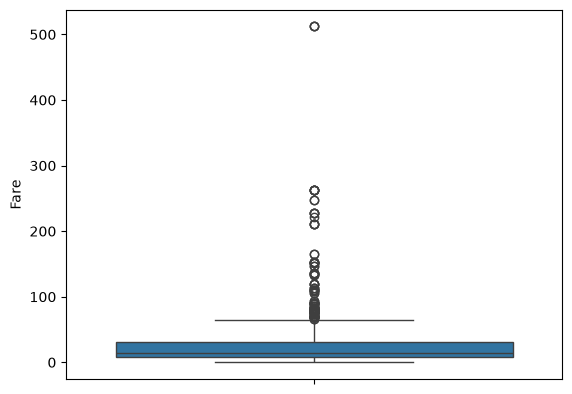

In [13]:
sns.boxplot(df_titanic['Fare'])

**Questions** :
   - Que représentent les points situés en dehors des moustaches du boxplot ? 
   - Comment pourriez-vous traiter ces valeurs aberrantes (les conserver, les supprimer, les transformer) ?

##### Cela représente les valeurs abérrantes ("hors-normes").
#####
##### En les supprimant, on risque de fausser les résultats du modèle, en les transformant il faut leur trouver une nouvelle valeur. Si on choisit de les garder, il faut investir dans mes modèles statistiques beaucoup plus robustes que la moyenne.

### Résumé de l'Analyse Exploratoire (EDA)

**Instructions** : Rédigez un résumé de vos observations. Notez les points suivants :
   - Les principales caractéristiques du dataset (variables, types de données, etc.).
   - Observations notables, comme les distributions de variables ou des corrélations importantes.
   - Quels aspects du dataset pourraient nécessiter des étapes de nettoyage et de transformation avant la modélisation.
   - ...


##### Avant de vouloir rechercher un modèle prédicitve, il faut s'assurer de la propreté, la fiabilité et de la compréhension des données. Comprendre le types de variables, les nombres de données (colonnes, lignes, etc..), les corrélations, mais aussi les valeurs manquantes et abbérantes est essentiel quand à la bonne préparation du futur modèle.
##### Ce qui fut intéressant jusqu'ici fut de comprendre la distinction entre variables catégorielles et numériques. 
##### Les denriers aspect à revoir dans ce dataset serait la transformation des valeurs manquantes, pour ne pas destabiliser l'apprentissage du modèle.

### 
---

## **4. Prétraitement des Données**

### Définition

Le **prétraitement des données** consiste à préparer les données pour l’entraînement du modèle. Il inclut le nettoyage des données, le traitement des valeurs manquantes, l’encodage des variables catégorielles, la gestion des valeurs aberrantes, et la normalisation.

### Objectifs du Prétraitement des Données

- **Assurer la qualité des données** : Traiter les valeurs manquantes et aberrantes pour éviter des biais dans les modèles.
- **Préparer les données pour les algorithmes** : Rendre les données exploitables pour le modèle choisi, en appliquant des transformations adaptées.

### Étapes du Prétraitement

---

### 1. Gestion des Valeurs Manquantes

La gestion des valeurs manquantes est essentielle pour garantir la qualité des données avant toute analyse ou modélisation. Les valeurs manquantes peuvent être traitées de différentes manières en fonction du type de variable et de la distribution des données. Voici les stratégies d’imputation couramment utilisées :

- **Moyenne** : Pour les variables continues avec une distribution symétrique et sans valeurs extrêmes.
- **Médiane** : Pour les variables continues susceptibles de contenir des valeurs extrêmes, car elle est moins sensible aux valeurs aberrantes.
- **Mode** : Pour les variables catégorielles, en remplaçant les valeurs manquantes par la catégorie la plus fréquente.
- **Suppression** : Pour les colonnes ayant plus de 70 % de valeurs manquantes, car elles contiennent peu d’informations exploitables.
- **Méthodes avancées** : Dans certains cas, des modèles de Machine Learning peuvent prédire les valeurs manquantes, mais cela nécessite des ressources supplémentaires et une analyse approfondie.

#### **Exemple d’Imputation pour la Colonne `Age`**

Pour la colonne `Age`, nous utilisons la **médiane** pour remplacer les valeurs manquantes, car cette variable continue contient des valeurs extrêmes. Utilisez `.fillna()` pour remplacer les valeurs manquantes


In [14]:
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

In [15]:
df_titanic['Age'].isna().sum()

np.int64(0)

**Question** : 
- Pourquoi utiliser la médiane peut-il être plus avantageux que la moyenne pour remplacer les valeurs manquantes ?

##### Utiliser la médiane est plus avantageux que la moyenne pour remplacer les valeurs manquantes lorsqu'il y a des valeurs extrêmes ou une distribution asymétrique dans les données. La moyenne change beaucoup si une valeur est très grande ou très petite, contrairement à la médiane qui est la valeur du milieu. Elle ne change pas si les chiffres extrêmes augmentent ou diminuent.

#### **Application des Stratégies pour les Autres Variables**

Pour les autres variables, choisissez la stratégie d’imputation appropriée selon la nature de la colonne :

- Utilisez la **moyenne** ou la **médiane** pour les variables continues, selon la présence de valeurs extrêmes.
- Utilisez le **mode** pour les variables catégorielles.
- Supprimez les colonnes avec un grand nombre de valeurs manquantes si elles contiennent plus de 70 % de données manquantes.

**Questions** :
- Quels sont les avantages et inconvénients d'utiliser la moyenne, la médiane ou le mode pour gérer les valeurs manquantes ?

#### La Moyenne : 
##### ++ : Utilise toutes les informations disponibles de la série de données. Simple et rapide à calculer pour des variables numériques continues.
##### -- : Très sensible aux valeurs extrêmes (aberrantes), qui faussent le résultat.Réduit artificiellement la variance et l'écart-type de la distribution. 
#### La Médiane : 
##### ++ : Robuste face aux valeurs extrêmes ou asymétriques.Reflète mieux le centre d'une distribution hétérogène (ex : les salaires)
##### -- : Ne tient pas compte de la valeur exacte de chaque observation.Moins efficace si la distribution est parfaitement normale et homogène. 
#### Le Mode
##### ++ : Applicable aux données qualitatives (catégorielles) où la moyenne et la médiane sont impossibles. Préserve la fréquence de la catégorie la plus populaire.
##### -- : Peut ignorer la grande majorité des autres données si une valeur domine peu.Impossible à définir ou peu pertinent s'il existe plusieurs modes (distribution multimodale) ou des valeurs toutes uniques.

---
### 2. **Calcule et Traitement des Valeurs Aberrantes avec la methode de l'IQR**

Une fois que nous avons identifié des valeurs aberrantes lors de l'exploration des données, nous pouvons maintenant les traiter dans la phase de prétraitement. Les valeurs aberrantes sont des observations extrêmes qui se situent en dehors de la majorité des données et peuvent affecter la performance de certains modèles de Machine Learning.

#### **Méthode de l'IQR pour le Traitement des Valeurs Aberrantes**

Pour repérer les valeurs aberrantes de manière quantitative, nous utilisons l'Intervalle Interquartile (`IQR`). En rappel, l'IQR est défini comme la différence entre le troisième quartile (`Q3`) et le premier quartile (`Q1`) : $IQR = Q3 - Q1$

Pour identifier les valeurs aberrantes, on utilise les bornes suivantes :
- **Borne inférieure** : $ Q1 - 1.5 \times IQR $
- **Borne supérieure** : $ Q3 + 1.5 \times IQR $

Les valeurs en dehors de cet intervalle sont considérées comme aberrantes.

##### **Étapes pour Traiter les Valeurs Aberrantes**

1. **Calcul des Quartiles et de l'IQR** :
   - Calculez les quartiles  `Q1` et `Q3`  pour les variables `Age` et `Fare`.
   - Déterminez l'IQR en soustrayant `Q1` de `Q3`.

2. **Détection des Valeurs Aberrantes** :
   - Calculez les bornes inférieure et supérieure pour chaque variable.
   - Filtrez les valeurs de `Age` et `Fare` qui se trouvent en dehors de ces bornes.

3. **Options pour le Traitement** :
   - **Suppression** : Supprimer les valeurs aberrantes si elles sont peu nombreuses et qu'elles risquent d'affecter le modèle.
   - **Transformation** : Appliquer une transformation (comme la transformation logarithmique) pour réduire l’impact des valeurs extrêmes.
   - **Imputation** : Remplacer les valeurs aberrantes par la médiane ou un autre résumé statistique si elles sont essentielles pour l’analyse.

**Instructions** :
- Calculez les valeurs de `Q1`, `Q3` et `IQR` pour `Age` et `Fare`.
- Déterminez les bornes pour filtrer les valeurs aberrantes et décidez comment les traiter en fonction du contexte.

1. **Calcul des Quartiles et de l'IQR** :

In [16]:
df_titanic[['Age','Fare']].describe()

,Age,Fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [17]:
df_titanic[['Age', 'Fare']].quantile([0.25, 0.75])

,Age,Fare
0.25,22.0,7.9104
0.75,35.0,31.0000


IQR Age :

In [18]:
iqr_age= df_titanic['Age'].quantile(0.75) - df_titanic['Age'].quantile(0.25)
iqr_age

np.float64(13.0)

IQR Fare :

In [19]:
iqr_fare= df_titanic['Fare'].quantile(0.75) - df_titanic['Fare'].quantile(0.25)
iqr_fare

np.float64(23.0896)

2. **Détection des Valeurs Aberrantes** :

Colonne Age :

In [20]:
borne_inf_age = df_titanic['Age'].quantile(0.25) - 1.5 * iqr_age
borne_inf_age

np.float64(2.5)

In [21]:
borne_sup_age = df_titanic['Age'].quantile(0.75) + 1.5 * iqr_age
borne_sup_age

np.float64(54.5)

Colonne Fare :

In [22]:
borne_inf_fare = df_titanic['Fare'].quantile(0.25) - 1.5 * iqr_age
borne_inf_fare

np.float64(-11.5896)

In [23]:
borne_sup_fare = df_titanic['Fare'].quantile(0.75) + 1.5 * iqr_age
borne_sup_fare

np.float64(50.5)

3. **Options pour le Traitement** :

**Questions** :
- Quels sont les avantages de transformer ou de supprimer les valeurs aberrantes dans `Age` et `Fare` ?
- Comment ces décisions pourraient-elles influencer les résultats de votre modèle de Machine Learning ?

##### Les différents avantages sont que la suppression des valeurs aberrantes, lorsqu'elles sont peu nombreuses, risquent d'affecter le modèle. Concernant la transformation (comme la transformation logarithmique) pour réduire l’impact des valeurs extrêmes. Enfin, l'imputation permet de remplacer les valeurs aberrantes par la médiane ou une autre statistique si elles sont essentielles pour l’analyse.
#####
##### Tout ces résultats peuvent interférer avec le modèle de machine learning car si les données ne sont pas de bonnes qualités et bien filtrer dès le début, les résultats seront eux aussi incorrect.

---

### 3. **Encodage des Variables Catégorielles**

1. **Encodage One-Hot** :
   - Utilisez `pd.get_dummies()` pour encoder les variables catégorielles (`Sex`, `Embarked`) en variables numériques.

In [24]:
df_titanic_encode = pd.get_dummies(df_titanic,columns = ['Sex','Embarked'])
df_titanic_encode.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,False,True,False,False,True


**Question** : Comment l’encodage des variables catégorielles peut-il aider certains algorithmes de Machine Learning à mieux traiter les données ?

##### L'encodage des variables catégorielles convertit des données textuelles en valeurs numériques pour que les algorithmes de calcul puissent les exploiter.

---

### 4. Normalisation et Standardisation des Variables

La **normalisation** et la **standardisation** sont des étapes importantes dans le prétraitement des données pour s’assurer que toutes les variables sont sur une même échelle. Cela évite que certaines variables, qui ont des valeurs plus grandes ou plus petites, influencent davantage le modèle que d'autres, simplement à cause de leur amplitude.

- **Normalisation** : La normalisation consiste à rescaler les données pour qu’elles soient comprises entre 0 et 1. Cela est utile lorsque les données contiennent des valeurs de tailles très différentes. Par exemple, si l’une des variables représente des montants financiers en milliers et qu'une autre représente des pourcentages, la normalisation permet de placer ces deux variables sur une échelle de 0 à 1, ce qui facilite les calculs et rend les valeurs comparables.

  Formule de la normalisation : $ x_{\text{norm}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$

- **Standardisation** : La standardisation consiste à transformer les données pour qu’elles aient une moyenne de 0 et un écart-type de 1. Cette méthode est utile lorsque les valeurs sont distribuées autour d’une moyenne mais avec des écarts variés. La standardisation centre les données autour de 0, ce qui aide à équilibrer leur influence dans les calculs du modèle.

  Formule de la standardisation :
  $ z = \frac{x - \mu}{\sigma}$, où $ \mu $ est la moyenne de la variable et $ \sigma $ est son écart-type.

**Pourquoi normaliser ou standardiser ?**  
Ces transformations sont appliquées pour que les variables aient une échelle comparable, ce qui permet d’éviter que certaines variables dominent les calculs simplement en raison de leur amplitude. Cela peut aussi améliorer la performance des modèles de Machine Learning qui sont sensibles aux différences d’échelle entre les variables, comme les modèles de distances.

##### **Instructions pour Appliquer la Normalisation et la Standardisation**

- **Normalisation** : Utilisez `MinMaxScaler` de `sklearn.preprocessing` pour transformer les variables numériques afin qu’elles soient comprises entre 0 et 1.

In [25]:
!pip install scikit-learn

In [26]:
import sklearn
sklearn.__version__

'1.9.0'

In [41]:
df_titanic[['Age']].shape

(891, 1)

In [82]:
from sklearn.preprocessing import MinMaxScaler
scaler_1 = MinMaxScaler()
colums_to_normalize_age = scaler_1.fit(df_titanic[['Age']])
colums_to_normalize_age

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[80.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[0.42]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[79.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Age']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,891


In [83]:
colums_to_normalize_age = scaler_1.transform(df_titanic[['Age']])

In [100]:
scaler_2 = MinMaxScaler()
colums_to_normalize_fare = scaler_2.fit_transform(df_titanic[['Fare']])

**Question** : Question : Pourquoi la normalisation pourrait-elle être utile pour certains types d’analyses ?

##### Cela est utile car elle permets d'équilibrer les échelles, et aide pour la convergence des modèles et l'interprétation des coefficients.

- **Standardisation** : Utilisez `StandardScaler` de `sklearn.preprocessing` pour transformer les variables numériques afin qu’elles aient une moyenne de 0 et un écart-type de 1.

In [51]:
from sklearn.preprocessing import StandardScaler
scaler_3 = StandardScaler()
colums_to_standardize_age = scaler_3.fit(df_titanic[['Age']])
colums_to_standardize_age

StandardScaler()

In [99]:
colums_to_standardize_age = scaler_3.transform(df_titanic[['Age']])

In [98]:
from sklearn.preprocessing import StandardScaler
scaler_4 = StandardScaler()
colums_to_standardize_fare = scaler_4.fit_transform(df_titanic[['Fare']])

In [60]:
df_titanic['normalisation_age'] = colums_to_normalize_age

In [61]:
df_titanic['normalisation_fare'] = colums_to_normalize_fare

In [62]:
df_titanic['standardisation_age'] = colums_to_standardize_fare

In [63]:
df_titanic['standardisation_fare'] = colums_to_standardize_fare

**Question** : Dans quel cas pensez-vous que la standardisation des données pourrait être importante ?

##### La standardisation peux aider les algorithmes type KNN ou Clustering dans leurs calculs de distance géométriques. De plus, elle optimise les calculs et est efficace dans la régularisation des pénalités sur les coefficients.

---
### Feature Engineering

Créer de nouvelles variables à partir des données existantes peut améliorer les performances du modèle. Par exemple :
   - **Membre de Famille** : Combinez `SibSp` (nombre de frères/sœurs/époux) et `Parch` (nombre de parents/enfants) pour créer une nouvelle variable représentant le nombre total de membres de la famille.

In [86]:
df_titanic['nb_total_famille'] = df_titanic['SibSp'] + df_titanic['Parch']
df_titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,nb_total_famille,normalisation_age,normalisation_fare,standardisation_age,standardisation_fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0.271174,0.014151,-0.502445,-0.502445
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0.472229,0.139136,0.786845,0.786845
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0.321438,0.015469,-0.488854,-0.488854
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0.434531,0.103644,0.420730,0.420730
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,0.434531,0.015713,-0.486337,-0.486337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,0.334004,0.025374,-0.386671,-0.386671
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,0.233476,0.058556,-0.044381,-0.044381
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S,3,0.346569,0.045771,-0.176263,-0.176263
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,0.321438,0.058556,-0.044381,-0.044381


**Question** : Comment l’ajout de cette nouvelle variable pourrait-il aider un modèle de Machine Learning à mieux prédire la survie ?

##### Cela peux aider le modèle, éviter les biais, et surtout éviter la fuite de données lors de la phase de test.

### Autres Étapes de Prétraitement

D'autres transformations peuvent être nécessaires selon les besoins :
   - **Transformation de l'âge en groupes d'âge** : Regroupez la colonne `Age` en catégories comme "Enfant", "Adolescent", "Adulte", "Senior".
   - **Transformation logarithmique** : Réduisez l'impact des valeurs extrêmes en appliquant une transformation logarithmique. Par exemple, appliquez `np.log1p()` sur la colonne `Fare`.

In [95]:
from sklearn.preprocessing import FunctionTransformer

def categories_age(X):
    bins = [0, 15, 60, 100]
    labels = ["Enfant", "Adulte", "Senior"]
    return pd.cut(X.to_numpy().flatten(), bins=bins, labels=labels, include_lowest=True).to_numpy().reshape(-1, 1)

transformateur_sur_mesure = FunctionTransformer(categories_age)

In [101]:
age_categorise = transformateur_sur_mesure.fit_transform(df_titanic[["Age"]])
age_categorise

array([['Adulte'],
       ['Adulte'],
       ['Adulte'],
       ['Adulte'],
       ['Adulte'],
       [nan],
       ['Adulte'],
       ['Enfant'],
       ['Adulte'],
       ['Enfant'],
       ['Enfant'],
       ['Adulte'],
       ['Adulte'],
       ['Adulte'],
       ['Enfant'],
       ['Adulte'],
       ['Enfant'],
       [nan],
       ['Adulte'],
       [nan],
       ['Adulte'],
       ['Adulte'],
       ['Enfant'],
       ['Adulte'],
       ['Enfant'],
       ['Adulte'],
       [nan],
       ['Adulte'],
       [nan],
       [nan],
       ['Adulte'],
       [nan],
       [nan],
       ['Senior'],
       ['Adulte'],
       ['Adulte'],
       [nan],
       ['Adulte'],
       ['Adulte'],
       ['Enfant'],
       ['Adulte'],
       ['Adulte'],
       [nan],
       ['Enfant'],
       ['Adulte'],
       [nan],
       [nan],
       [nan],
       [nan],
       ['Adulte'],
       ['Enfant'],
       ['Adulte'],
       ['Adulte'],
       ['Adulte'],
       ['Senior'],
       [nan],
       ['Ad

In [89]:
pd.Series(age_categorise.flatten()).value_counts(dropna=False)

Adulte    786
Enfant     83
Senior     22
Name: count, dtype: int64

##### Le découpage des catégories à été repensé car à l'époque du Titanic (au début du XXème siècle), on était considérés adultes à partir de 14-15 ans, ce qui signifie que plusieurs adolescents de 14 et 15 ans (et plus) ont ainsi péri car ils étaient considérés comme des adultes en âge de rester sur le navire. À cet âge, ils devaient céder leur place et appliquer la règle « les femmes et les enfants d'abord ». 

In [92]:
df_titanic['Fare_log'] = np.log1p(df_titanic['Fare'])

**Conversions des Transformations** :
   - **Binning (ou catégorisation)** : Transformer des variables continues comme l'âge en groupes d'âge.
   - **Log transformation** : Appliquée sur des valeurs numériques étendues pour en réduire la dispersion.

**Question** : Comment ces transformations peuvent-elles affecter la distribution des données ? Dans quel cas sont-elles nécessaires ?

##### Ces transformations peuvent affecter la distribution des données en changeant les données dans la variable (la sépareant ou en changeant d'échelle). Ces transformations sont nécessaires quand les données présentent des grands écarts de valeurs ou si la distribution est assymétrique

---

## **Résumé et Conclusion**

Dans ce module, vous avez appris :
- Découvert les applications du Machine Learning en entreprise.
- L'importance de l'exploration des données et les outils pour l'EDA.
- Les techniques de prétraitement des données : gestion des valeurs manquantes, encodage, normalisation, valeurs aberrantes, et **feature engineering**.

Ces compétences sont cruciales pour préparer des données prêtes pour la modélisation en Machine Learning.